In [6]:
#NLP
import spacy
import scispacy
from scispacy.linking import EntityLinker

#Grafo de Conhecimento
import networkx as nx
import matplotlib.pyplot as plt

In [7]:
nlp = spacy.load("en_ner_bc5cdr_md")
nlp.add_pipe("scispacy_linker", config={"resolve_abbreviations": True, "linker_name": "mesh"})

texts = [
    "Creatine supplementation may be associated with alopecia or baldness in some patients.",
    "Long-term use of rosuvastatin has been linked to an increased risk of diabetes mellitus in elderly patients.",
    "Methotrexate administration can lead to hepatotoxicity and liver fibrosis after prolonged exposure.",
    "Patients treated with amiodarone frequently develop pulmonary toxicity and thyroid dysfunction.",
    "Ibuprofen overdose is a well-documented cause of acute renal failure and gastrointestinal bleeding.",
    "Lithium carbonate, commonly prescribed for bipolar disorder, may induce nephrogenic diabetes insipidus over time.",
]


doc = nlp(texts[2])

for ent in doc.ents:
    print(f"\nEntidade : {ent.text}")
    print(f"Tipo     : {ent.label_}")
    for kb_ent in ent._.kb_ents:
        cui, score = kb_ent
        print(f"MeSH ID  : {cui}  |  score: {score:.3f}")


Entidade : Methotrexate
Tipo     : CHEMICAL
MeSH ID  : C0025677  |  score: 0.957
MeSH ID  : C0949359  |  score: 0.802

Entidade : hepatotoxicity
Tipo     : DISEASE
MeSH ID  : C0235280  |  score: 0.726
MeSH ID  : C1527358  |  score: 0.709

Entidade : fibrosis
Tipo     : DISEASE
MeSH ID  : C0016059  |  score: 0.983
MeSH ID  : C0016053  |  score: 0.760
MeSH ID  : C0010674  |  score: 0.757
MeSH ID  : C0239946  |  score: 0.750
MeSH ID  : C0016048  |  score: 0.723


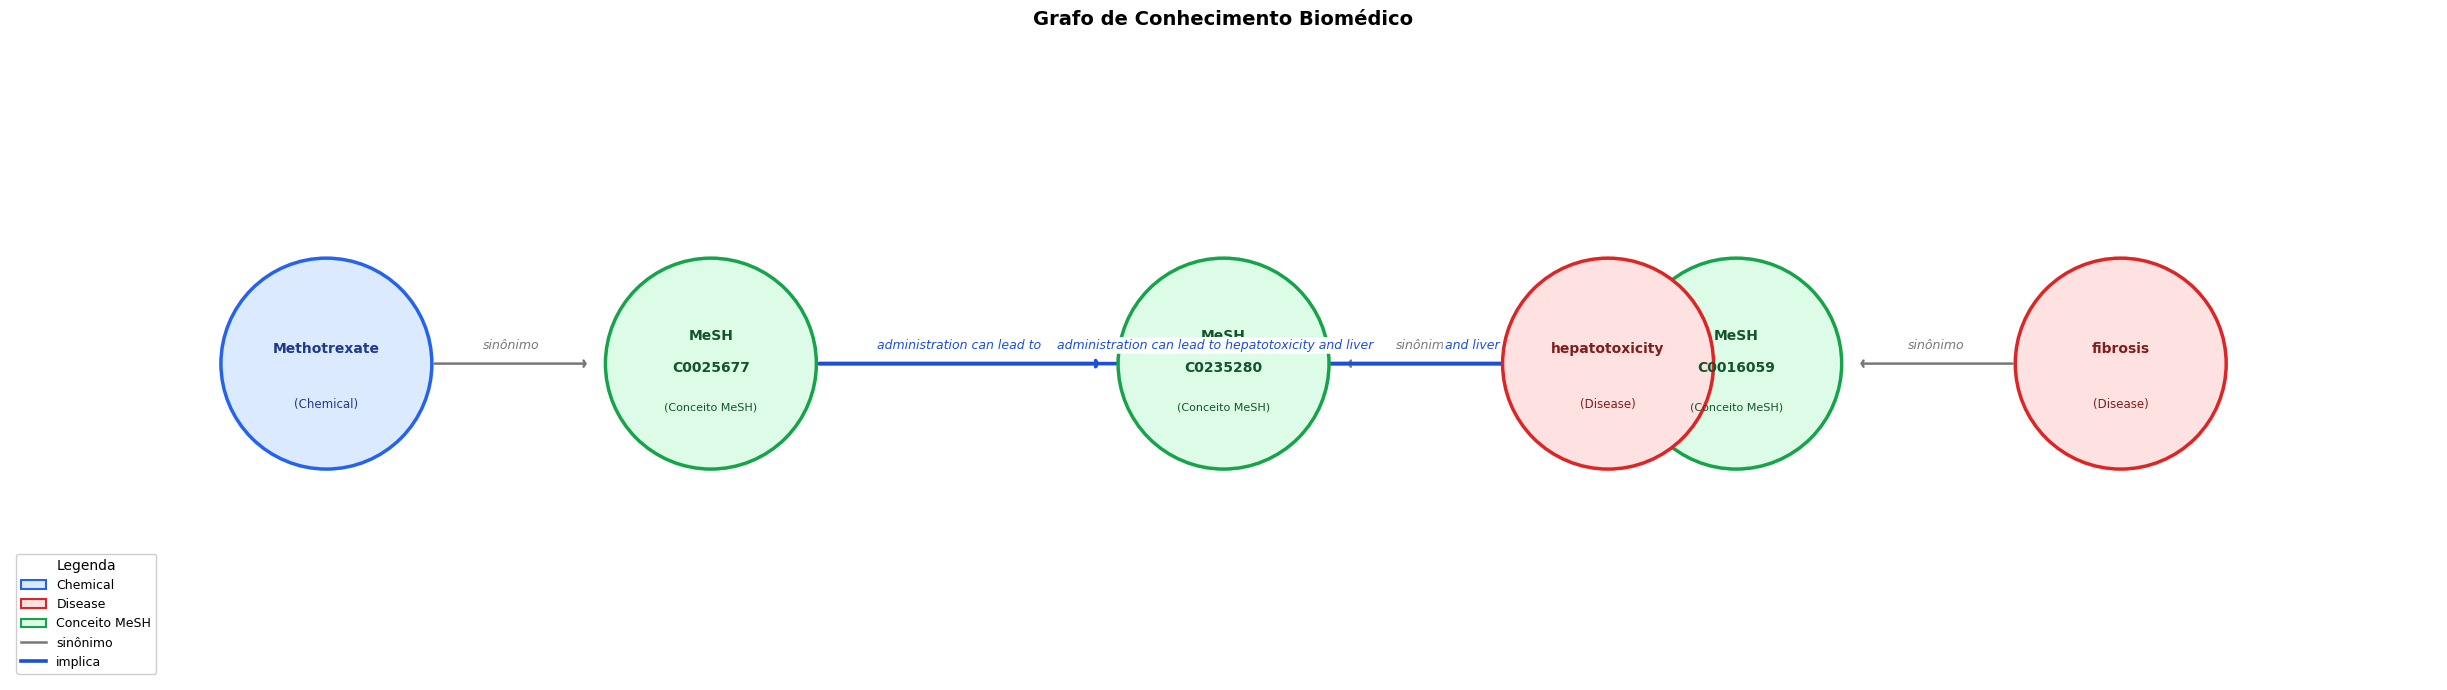

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Circle
from matplotlib.lines import Line2D
import networkx as nx
import numpy as np

ENTITY_STYLE = {
    "CHEMICAL": {"face": "#dbeafe", "edge": "#2563eb", "text": "#1e3a8a"},
    "DISEASE":  {"face": "#fee2e2", "edge": "#dc2626", "text": "#7f1d1d"},
}
MESH_STYLE = {"face": "#dcfce7", "edge": "#16a34a", "text": "#14532d"}

# ── Construção do grafo ───────────────────────────────────────────────────────
G = nx.DiGraph()
text_to_mesh = {}
seen_meshes  = set()

for ent in doc.ents:
    mesh_id = ent._.kb_ents[0][0] if ent._.kb_ents else None
    ent_id  = f"ent::{ent.text}"
    G.add_node(ent_id, tipo=ent.label_, kind="entity", label=ent.text)
    text_to_mesh[ent.text] = mesh_id
    if mesh_id:
        if mesh_id not in seen_meshes:
            G.add_node(mesh_id, tipo=ent.label_, kind="mesh",
                       label=f"MeSH\n{mesh_id}")
            seen_meshes.add(mesh_id)
        G.add_edge(ent_id, mesh_id, label="sinônimo")

def get_relation(doc, ent_a, ent_b):
    first, second = (ent_a, ent_b) if ent_a.start < ent_b.start else (ent_b, ent_a)
    tokens = doc[first.end:second.start]
    rel = " ".join(t.text for t in tokens if not t.is_punct).strip()
    return rel or "relacionado a"

ents = list(doc.ents)
seen_pairs = set()
for i, ent_a in enumerate(ents):
    for ent_b in ents[i + 1:]:
        mid_a = text_to_mesh.get(ent_a.text)
        mid_b = text_to_mesh.get(ent_b.text)
        if mid_a and mid_b and mid_a != mid_b:
            if ent_a.start < ent_b.start:
                src, dst, e_src, e_dst = mid_a, mid_b, ent_a, ent_b
            else:
                src, dst, e_src, e_dst = mid_b, mid_a, ent_b, ent_a
            if (src, dst) not in seen_pairs:
                seen_pairs.add((src, dst))
                G.add_edge(src, dst, label=get_relation(doc, e_src, e_dst))

# ── Layout: MeSH em linha, entidades agrupadas ao lado do seu MeSH ────────────
def compute_layout(G, H=3.5, V=1.6):
    mesh_nodes = [n for n in G.nodes if G.nodes[n].get("kind") == "mesh"]
    sem_edges  = [(u, v) for u, v, d in G.edges(data=True)
                  if u in mesh_nodes and v in mesh_nodes]
    mesh_sub = nx.DiGraph()
    mesh_sub.add_nodes_from(mesh_nodes)
    mesh_sub.add_edges_from(sem_edges)
    try:
        order = list(nx.topological_sort(mesh_sub))
    except Exception:
        order = list(mesh_nodes)

    mesh_pos = {n: (i * H, 0.0) for i, n in enumerate(order)}
    pos = dict(mesh_pos)
    sources = {u for u, v in sem_edges}
    targets = {v for u, v in sem_edges}

    for mesh_id in mesh_nodes:
        mx, my = mesh_pos[mesh_id]
        children = [u for u, v in G.edges()
                    if v == mesh_id and G.nodes[u].get("kind") == "entity"]
        n = len(children)
        if not children:
            continue
        x_off = -(H * 0.75) if (mesh_id in sources and mesh_id not in targets) else (H * 0.75)
        for j, ent in enumerate(children):
            pos[ent] = (mx + x_off, (j - (n - 1) / 2) * V)
    return pos

pos = compute_layout(G)
R = 0.72
PAD = R * 3.0

xs = [x for x, y in pos.values()]
ys = [y for x, y in pos.values()]
x_min, x_max = min(xs) - PAD, max(xs) + PAD
y_min, y_max = min(ys) - PAD, max(ys) + PAD
xspan, yspan = x_max - x_min, y_max - y_min

fig_h = 7.0
fig_w = fig_h * (xspan / yspan)
fig, ax = plt.subplots(figsize=(fig_w, fig_h))
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_aspect("equal")
ax.set_facecolor("white")
fig.patch.set_facecolor("white")
ax.axis("off")

# ── Arestas ───────────────────────────────────────────────────────────────────
for u, v, d in G.edges(data=True):
    pu, pv = np.array(pos[u]), np.array(pos[v])
    delta = pv - pu
    dist  = np.linalg.norm(delta)
    if dist < 1e-6:
        continue
    direc = delta / dist
    start = pu + direc * R
    end   = pv - direc * R * 1.15

    is_syn = d["label"] == "sinônimo"
    color  = "#777"    if is_syn else "#1d4ed8"
    lw     = 1.8       if is_syn else 2.6

    ax.annotate("", xy=end, xytext=start,
                arrowprops=dict(
                    arrowstyle="->, head_width=0.22, head_length=0.13",
                    color=color, lw=lw),
                zorder=1)

    mid = (start + end) / 2
    ax.text(mid[0], mid[1] + 0.08, d["label"],
            ha="center", va="bottom",
            fontsize=9, fontstyle="italic", color=color,
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none"),
            zorder=5)

# ── Nós (círculos reais + texto em camadas) ────────────────────────────────────
for node, (x, y) in pos.items():
    kind  = G.nodes[node].get("kind", "entity")
    tipo  = G.nodes[node].get("tipo", "")
    label = G.nodes[node].get("label", node)
    style = ENTITY_STYLE.get(tipo) if kind == "entity" else MESH_STYLE

    ax.add_patch(Circle((x, y), R,
                        facecolor=style["face"],
                        edgecolor=style["edge"],
                        linewidth=2.5, zorder=2))

    if kind == "entity":
        ax.text(x, y + 0.10, label,
                ha="center", va="center",
                fontsize=10, fontweight="bold", color=style["text"], zorder=3)
        ax.text(x, y - 0.28, f"({tipo.title()})",
                ha="center", va="center",
                fontsize=8.5, color=style["text"], zorder=3)
    else:
        parts = label.split("\n")
        ax.text(x, y + 0.19, parts[0],
                ha="center", va="center",
                fontsize=10, fontweight="bold", color=style["text"], zorder=3)
        ax.text(x, y - 0.03, parts[1] if len(parts) > 1 else "",
                ha="center", va="center",
                fontsize=10, fontweight="bold", color=style["text"], zorder=3)
        ax.text(x, y - 0.30, "(Conceito MeSH)",
                ha="center", va="center",
                fontsize=8, color=style["text"], zorder=3)

# ── Legenda ───────────────────────────────────────────────────────────────────
leg = [
    mpatches.Patch(facecolor=ENTITY_STYLE["CHEMICAL"]["face"],
                   edgecolor=ENTITY_STYLE["CHEMICAL"]["edge"], lw=1.5, label="Chemical"),
    mpatches.Patch(facecolor=ENTITY_STYLE["DISEASE"]["face"],
                   edgecolor=ENTITY_STYLE["DISEASE"]["edge"], lw=1.5, label="Disease"),
    mpatches.Patch(facecolor=MESH_STYLE["face"],
                   edgecolor=MESH_STYLE["edge"], lw=1.5, label="Conceito MeSH"),
    Line2D([0], [0], color="#777", lw=1.8, label="sinônimo"),
    Line2D([0], [0], color="#1d4ed8", lw=2.6, label="implica"),
]
ax.legend(handles=leg, loc="lower left",
          title="Legenda", title_fontsize=10,
          fontsize=9, framealpha=0.95, edgecolor="#ccc")
ax.set_title("Grafo de Conhecimento Biomédico",
             fontsize=14, fontweight="bold", pad=16)
plt.tight_layout()
plt.show()